I denna labben har jag testat en förtränad CNN(resnet18) och bara kollat hur den ser på en bild via en heatmap. Tack vare denna heatmapen kan vi se hur den tar besluten den gör och vart den lägger vikt i bilden för att bestämma sig

In [1]:
import matplotlib.pyplot as plt
import torch

from torchvision.transforms.v2.functional import to_pil_image
from torchvision.models import get_model, get_model_weights
from torchvision.io import decode_image

from torchcam.utils import overlay_mask
from torchcam.methods import LayerCAM

from pathlib import Path

Modellen som valts är "resnet18" som har varit passande vid detta tillfället då det är en vältränad modell som funkar väldigt smidigt när man inte har den bästa datorn att jobba med

In [2]:
images_dir = Path(r"C:\Users\frolu\OneDrive\Skrivbord\skol kodning\Book")

weights = get_model_weights("resnet18").DEFAULT
model = get_model("resnet18", weights=weights).eval()

preprocess = weights.transforms()

cam_extractor = LayerCAM(model, target_layer="layer4")

Bilderna som valts att använda va av en chimpans, Lemur, Nebbdjur, Svärds-haj, Barr-träd och en palm som inte blev som tänkt som man kommer se senare i programmet

In [3]:

picturs = [
    "chimpans.png",
    "Lemur.png",
    "nebbdjur.png",
    "sverd_haj.png",
    "Barr_tred.png",
    "palm.png"

]

idx_to_label = weights.meta["categories"]

for pic in picturs:
    img = decode_image(pic)
    input_tensor = preprocess(img).unsqueeze(0)

    out = model(input_tensor)

    probs = torch.softmax(out, dim=1)
    top_probs, top_idxs = probs.topk(5, dim=1)

    print(f"\nBild: {pic}")

    for i in range(5):
        idx = top_idxs[0, i].item()
        prob = top_probs[0, i].item()
        name = idx_to_label[idx]

        print(f"{i+1}. {name} ({prob:.3f})")


Bild: chimpans.png
1. chimpanzee (0.998)
2. spider monkey (0.001)
3. langur (0.001)
4. siamang (0.000)
5. macaque (0.000)

Bild: Lemur.png
1. Madagascar cat (0.950)
2. indri (0.050)
3. koala (0.000)
4. gibbon (0.000)
5. mongoose (0.000)

Bild: nebbdjur.png
1. platypus (1.000)
2. otter (0.000)
3. beaver (0.000)
4. mink (0.000)
5. brown bear (0.000)

Bild: sverd_haj.png
1. hammerhead (0.683)
2. tiger shark (0.210)
3. great white shark (0.098)
4. gar (0.003)
5. killer whale (0.002)

Bild: Barr_tred.png
1. worm fence (0.147)
2. lakeside (0.101)
3. maze (0.039)
4. bison (0.036)
5. mountain bike (0.031)

Bild: palm.png
1. seashore (0.800)
2. sandbar (0.093)
3. sea urchin (0.027)
4. tarantula (0.013)
5. lakeside (0.010)


kommer imon 05/04

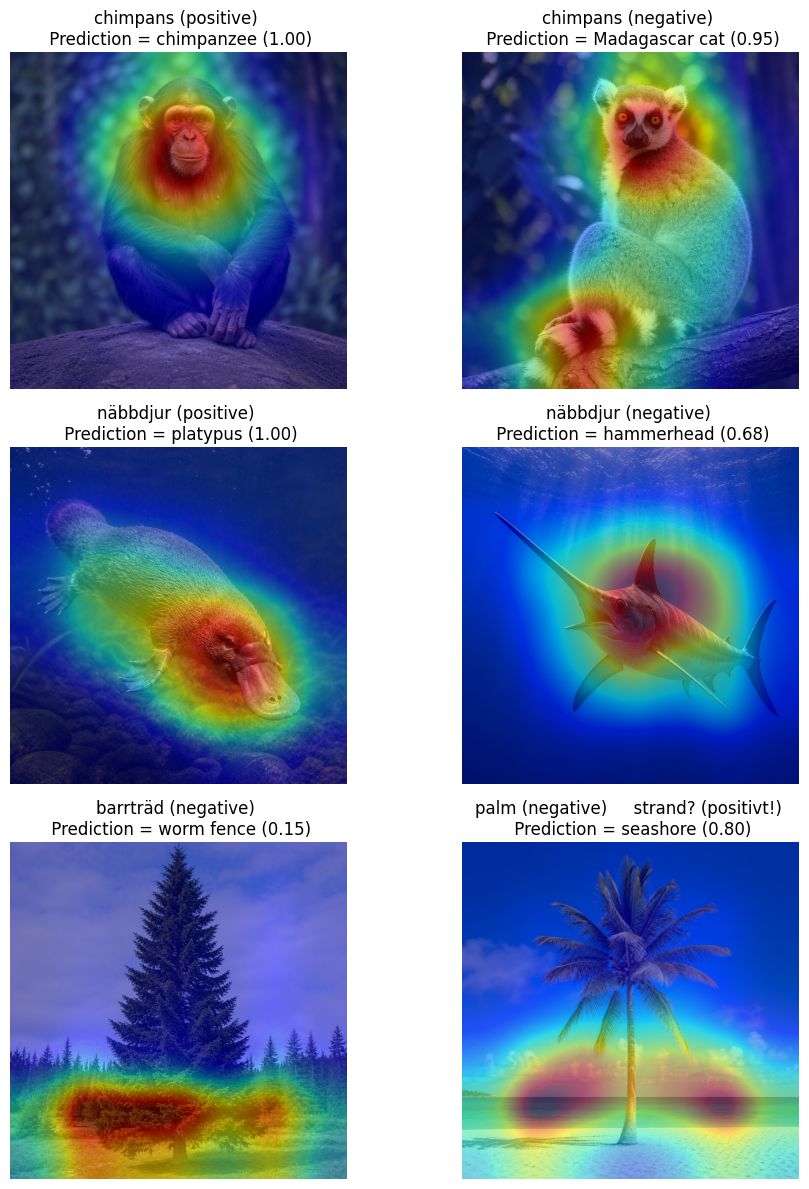

In [4]:
picturs = [
    ("chimpans.png", "chimpans", "positive"),
    ("Lemur.png", "chimpans", "negative"),

    ("nebbdjur.png", "näbbdjur", "positive"),
    ("sverd_haj.png", "näbbdjur", "negative"),

    ("Barr_tred.png", "barrträd", "negative"),
    ("palm.png", "palm", "negative)     strand? (positivt!"),
]

idx_to_label = weights.meta["categories"]

fig, axes = plt.subplots(3, 2, figsize=(10, 12))
axes = axes.flatten()

for ax, (file, name, label_type) in zip(axes, picturs):
    img = decode_image(file)
    
    out = model(preprocess(img).unsqueeze(0))

    probability = torch.softmax(out, dim=1)
    predictions_index = probability.argmax(dim=1).item()
    predictions_name = idx_to_label[predictions_index]
    confidence = probability[0, predictions_index].item()

    activation_map = cam_extractor(predictions_index, out)

    result = overlay_mask(
        to_pil_image(img),
        to_pil_image(activation_map[0].squeeze(0), mode='F'),
        alpha=0.5
    )

    ax.imshow(result)
    ax.set_title(f"{name} ({label_type}) \n Prediction = {predictions_name} ({confidence:.2f})")
    ax.axis("off")

plt.tight_layout()
plt.show()

här märker vi väldigt snabbt att nätverket inte riktigt kan identifiera dom korreta sakerna vi just va ute efter men samtidigt ser den saker som är liknande eller i bakgrunden fram tills vi kommer till barrträdet som den inte alls vet vad det är och kollar lite konstigt på det. så man kan konstatera att den inte tränats speciellt bra på just denna sortens objekt

förbättras imon